<a href="https://colab.research.google.com/github/Greysvm99/CryptoExchangeSystem_GlobantP/blob/init-data/Taller_S3_Mi_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller S3 – Conteo de personas en video

**Proyecto seleccionado:** Contador de personas  
**Video utilizado:** Gente caminando.mp4

## Objetivo

Aplicar un sistema de visión por computador para detectar y contar personas que cruzan una línea definida en un video. Se utilizó YOLO para la detección de personas y se calibró la posición de la línea de conteo de acuerdo con las características del video.

Como funcionalidad adicional, se implementó una alerta de ocupación visible que se activa cuando se detectan más de 15 personas simultáneamente en pantalla.

In [3]:
## 1. Preparación del entorno

!git clone https://github.com/capo2786/ejercicios-python.git

Cloning into 'ejercicios-python'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 65 (delta 16), reused 65 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 29.45 MiB | 26.01 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [4]:
# Se instala la librería Ultralytics necesaria para utilizar YOLO.
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 741.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 7.7 MB/s eta 0:00:00


In [5]:
%cd /content/ejercicios-python/01-contador-personas

/content/ejercicios-python/01-contador-personas


## 2. Carga del video

In [8]:
# Subir video a Google Colab
from google.colab import files

archivos = files.upload()

Saving Gente caminando.mp4 to Gente caminando.mp4


## 3. Calibración de la línea de conteo

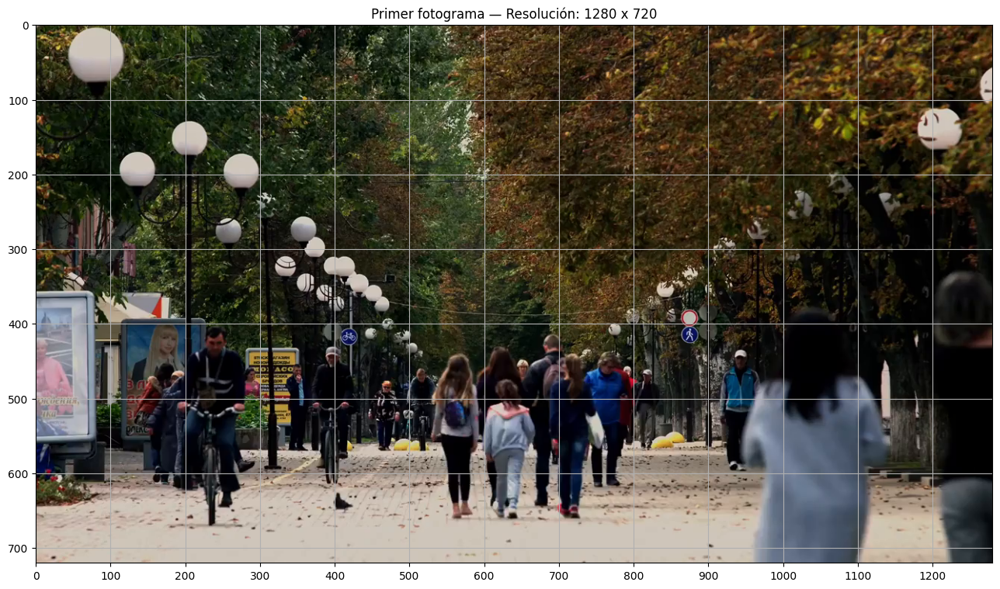

In [5]:
# Colocar Cuadrícula con coordenadas en el primer cuadro del video
import cv2
import matplotlib.pyplot as plt

video = "Gente caminando.mp4"

cap = cv2.VideoCapture(video)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    alto, ancho = frame_rgb.shape[:2]

    plt.figure(figsize=(16, 9))
    plt.imshow(frame_rgb)

    # Cuadrícula cada 100 píxeles
    plt.xticks(range(0, ancho, 100))
    plt.yticks(range(0, alto, 100))

    plt.grid()
    plt.xlim(0, ancho)
    plt.ylim(alto, 0)

    plt.title(f"Primer fotograma — Resolución: {ancho} x {alto}")
    plt.show()

else:
    print("No se pudo leer el video.")

In [7]:
# Calibramos la línea horizontal desde donde inicia a donde termina
import json

nueva_linea = {
    "linea": [[250, 550], [1050, 550]]
}

with open("linea.json", "w") as archivo:
    json.dump(nueva_linea, archivo)

print("Nueva línea guardada:", nueva_linea)

Nueva línea guardada: {'linea': [[250, 550], [1050, 550]]}


In [18]:
# verificacion visual de la linea horizontal para el conteo de personal
from IPython.display import Video

Video(
    "/content/prueba_linea_h264.mp4",
    embed=True,
    width=900
)

aparecen cruces en 0:00:00. Eso ocurre porque al comenzar el video ya hay personas sobre/cerca de la línea y el tracker puede interpretar sus primeros movimientos como cruces.

## 4. Funcionalidad adicional: control de ocupación visible

In [10]:
#Crear una tabla de columnas que guardan los datos obtenidos del video
import pandas as pd

# Leer los datos generados por el contador
ocupacion = pd.read_csv("ocupacion_final.csv")

# Límite que definimos para nuestro plus
LIMITE_PERSONAS = 15

# Máximo registrado en el CSV
max_visibles = ocupacion["visibles"].max()

# Primer momento en que se alcanza el máximo
fila_max = ocupacion.loc[ocupacion["visibles"].idxmax()]
tiempo_max = fila_max["t_video_s"]

# Momentos donde se supera el límite
superaciones = ocupacion[ocupacion["visibles"] > LIMITE_PERSONAS]

print("===== ANÁLISIS DE OCUPACIÓN =====")
print(f"Límite establecido: {LIMITE_PERSONAS} personas")
print(f"Máximo registrado: {max_visibles} personas")
print(f"Primer momento del máximo: {tiempo_max:.2f} segundos")

if not superaciones.empty:
    primera = superaciones.iloc[0]
    print("⚠️ LÍMITE DE OCUPACIÓN SUPERADO")
    print(f"Primera superación: {primera['t_video_s']:.2f} segundos")
    print(f"Personas detectadas: {int(primera['visibles'])}")
else:
    print("✅ El límite no fue superado")

===== ANÁLISIS DE OCUPACIÓN =====
Límite establecido: 15 personas
Máximo registrado: 17 personas
Primer momento del máximo: 4.04 segundos
⚠️ LÍMITE DE OCUPACIÓN SUPERADO
Primera superación: 2.04 segundos
Personas detectadas: 16


In [11]:
!cp contador.py contador_plus.py

## 5. Ejecución del sistema

In [15]:
archivo = "contador_plus.py"

with open(archivo, "r", encoding="utf-8") as f:
    codigo = f.read()

codigo = codigo.replace(
'''    # Alerta visual: marco rojo si hay mas gente que el aforo permitido
    if aforo_max < 9999 and a > aforo_max:
        cv2.rectangle(out, (0, 0), (W - 1, H - 1), RED, 6)
        cv2.putText(out, "AFORO EXCEDIDO", (W // 2 - 130, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, RED, 3, cv2.LINE_AA)''',

'''    # PLUS: alerta cuando se supera el limite de personas visibles
    LIMITE_VISIBLES = 15

    if len(personas) > LIMITE_VISIBLES:
        cv2.rectangle(out, (0, 0), (W - 1, H - 1), RED, 6)

        cv2.putText(out, "LIMITE DE OCUPACION SUPERADO",
                    (W // 2 - 260, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, RED, 3, cv2.LINE_AA)

        cv2.putText(out,
                    f"{len(personas)} / {LIMITE_VISIBLES} PERSONAS VISIBLES",
                    (W // 2 - 190, 75),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, RED, 2, cv2.LINE_AA)'''
)

with open(archivo, "w", encoding="utf-8") as f:
    f.write(codigo)

print("✅ Alerta de ocupación visible agregada a contador_plus.py")

✅ Alerta de ocupación visible agregada a contador_plus.py


In [16]:
# Se ejecuta para visualizar que el control de limite de aforo esté funcionando.
!python contador_plus.py "Gente caminando.mp4" \
    --motor yolo \
    --modelo yolov8n.pt \
    --conf 0.35 \
    --csv conteo_plus.csv \
    --serie-csv ocupacion_plus.csv \
    --headless \
    --record video_final_plus.mp4

[video] Gente caminando.mp4  1280x720  25.00 FPS  598 cuadros  0:00:23
[config] linea desde linea.json
[detector] motor: yolo
Procesando...  (q = salir)

  [0:00:00] ENTRADA  persona #1  ->  aforo=1

  [0:00:00] SALIDA  persona #7  ->  aforo=0

  [0:00:00] SALIDA  persona #6  ->  aforo=-1
   33.3%  t=0:00:07  visibles=14  in=1 out=2 aforo=-1   
  [0:00:08] SALIDA  persona #4  ->  aforo=-2
   45.8%  t=0:00:10  visibles=14  in=1 out=3 aforo=-2   
  [0:00:11] ENTRADA  persona #2  ->  aforo=-1
   70.9%  t=0:00:16  visibles=18  in=2 out=3 aforo=-1   
  [0:00:17] ENTRADA  persona #39  ->  aforo=0
   79.3%  t=0:00:18  visibles=13  in=3 out=3 aforo=0   
  [0:00:19] SALIDA  persona #24  ->  aforo=-1
   83.4%  t=0:00:19  visibles=12  in=3 out=4 aforo=-1   
  [0:00:20] ENTRADA  persona #5  ->  aforo=0

  [0:00:20] SALIDA  persona #43  ->  aforo=-1
   96.0%  t=0:00:22  visibles=14  in=4 out=5 aforo=-1   
  [0:00:23] ENTRADA  persona #21  ->  aforo=0

Fin del video.

Cuadros procesados : 597
Tiempo

## 6. Resultados

## 7. Video procesado

In [17]:
# Ejecutar el video

!ffmpeg -y -loglevel error \
    -i video_final_plus.mp4 \
    -vcodec libx264 \
    -pix_fmt yuv420p \
    video_final_entrega.mp4

print("✅ Video convertido correctamente")

✅ Video convertido correctamente


In [18]:
from IPython.display import Video

Video("video_final_entrega.mp4", embed=True, width=900)

## 8. Análisis de ocupación visible

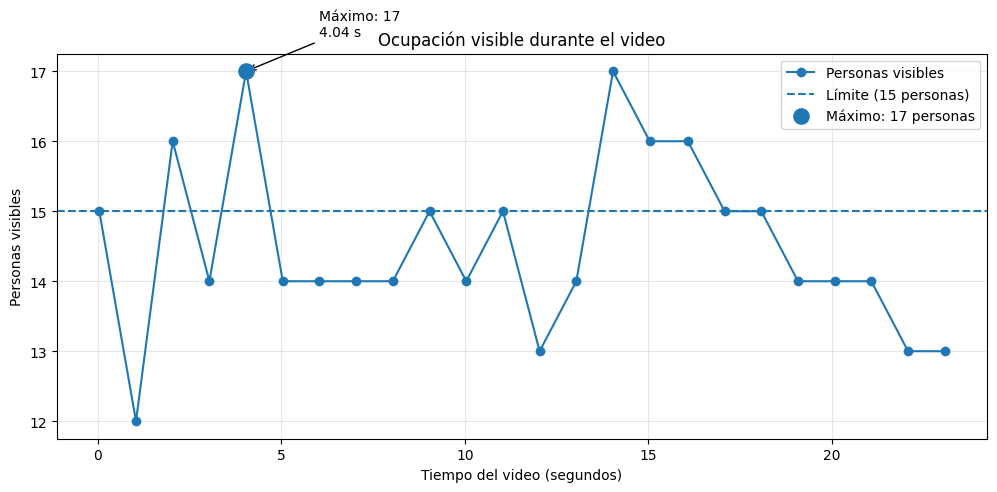

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

ocupacion = pd.read_csv("ocupacion_plus.csv")
LIMITE_PERSONAS = 15

plt.figure(figsize=(12, 5))

# Evolución de personas visibles
plt.plot(
    ocupacion["t_video_s"],
    ocupacion["visibles"],
    marker="o",
    label="Personas visibles"
)

# Límite establecido
plt.axhline(
    y=LIMITE_PERSONAS,
    linestyle="--",
    label=f"Límite ({LIMITE_PERSONAS} personas)"
)

# Punto de máxima concentración
indice_max = ocupacion["visibles"].idxmax()
tiempo_max = ocupacion.loc[indice_max, "t_video_s"]
personas_max = ocupacion.loc[indice_max, "visibles"]

plt.scatter(
    tiempo_max,
    personas_max,
    s=120,
    zorder=5,
    label=f"Máximo: {personas_max} personas"
)

plt.annotate(
    f"Máximo: {personas_max}\n{tiempo_max:.2f} s",
    xy=(tiempo_max, personas_max),
    xytext=(tiempo_max + 2, personas_max + 0.5),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Tiempo del video (segundos)")
plt.ylabel("Personas visibles")
plt.title("Ocupación visible durante el video")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## 9. Conclusiones

La calibración de la línea permitió adaptar el contador al video seleccionado y registrar los cruces de personas en una zona adecuada de la escena.

El sistema detectó 5 entradas y 5 salidas y alcanzó un pico instantáneo de 19 personas visibles. Como funcionalidad adicional, se implementó una alerta visual para detectar situaciones en las que aparecen más de 15 personas simultáneamente.

Este ejercicio también evidencia que el aforo calculado mediante entradas y salidas depende de las condiciones iniciales del video. Cuando existen personas en la escena desde el primer fotograma, la cantidad de personas visibles constituye una medida complementaria útil para analizar la ocupación.